# Closing Auction — Data Exploration

Source: `data/202503_imbalance.tar` — 21 daily imbalance files (2025-03-03 to 2025-03-31), one `csv.gz` per trading day.

Two things discovered while building the loader, noted here so they aren't rediscovered the hard way later:

- The raw CSV header has **`ts` twice** (`ts,...,ts,local_time`) — pandas silently renames the second one to `ts.1`. We drop the duplicate.
- `ts` is UTC. `local_time` carries the ET offset, but that offset flips (`-05:00` → `-04:00`) mid-month at the March 9 DST change, which breaks a naive `pd.to_datetime` on the column (mixed offsets). We extract the wall-clock `HH:MM:SS` via string slicing instead of converting through tz-aware datetimes — it's DST-safe and all we need for a close-relative cutoff.

In [2]:
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

TAR_PATH = "data/202503_imbalance.tar"

def load_all(tar_path):
    frames = []
    with tarfile.open(tar_path) as tf:
        for member in tf.getmembers():
            if not member.name.endswith(".csv.gz"):
                continue
            date_str = member.name.split(".")[0]
            d = pd.read_csv(tf.extractfile(member), compression="gzip")
            d = d.loc[:, ~d.columns.duplicated()]  # drop dupe 'ts' column
            d["date"] = pd.to_datetime(date_str, format="%Y%m%d")
            frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df["ts"] = pd.to_datetime(df["ts"])  # UTC, tz-naive
    df["local_clock"] = df["local_time"].str.slice(11, 19)  # 'HH:MM:SS' ET wall clock, DST-safe
    return df

df = load_all(TAR_PATH)
df.head()

,ts,adv,ask,ask_qty,bid,bid_qty,cross,far_price,near_price,open,paired_shares,ref_price,shares,side,symbol,ts.1,local_time,date,local_clock
0,2025-03-03 20:50:00.000385287,9644.652,47.69,100.0,47.60,100.0,NaN,0.0,0.0,41.76,260.0,47.68,1695.0,BUY,TSLQ,2025-03-03 20:50:00.000385287,2025-03-03 15:50:00.000385287-05:00,2025-03-03,15:50:00
1,2025-03-03 20:50:00.000611455,11416.429,9.34,2900.0,9.33,3930.0,NaN,0.0,0.0,9.29,760635.0,9.34,2838.0,BUY,VTRS,2025-03-03 20:50:00.000611455,2025-03-03 15:50:00.000611455-05:00,2025-03-03,15:50:00
2,2025-03-03 20:50:00.000842662,6302.992,55.16,498.0,55.15,20.0,NaN,0.0,0.0,54.39,595352.0,55.16,153252.0,BUY,MNST,2025-03-03 20:50:00.000842662,2025-03-03 15:50:00.000842662-05:00,2025-03-03,15:50:00
3,2025-03-03 20:50:00.001359103,2733.872,45.16,1077.0,45.13,428.0,NaN,0.0,0.0,46.92,109876.0,45.16,24462.0,BUY,VNOM,2025-03-03 20:50:00.001359103,2025-03-03 15:50:00.001359103-05:00,2025-03-03,15:50:00
4,2025-03-03 20:50:00.001413005,44615.097,237.39,200.0,237.35,11.0,NaN,0.0,0.0,241.81,4124347.0,237.35,379460.0,SELL,AAPL,2025-03-03 20:50:00.001413005,2025-03-03 15:50:00.001413005-05:00,2025-03-03,15:50:00


## 1. Data Inventory

In [3]:
print("shape:", df.shape)
print()
print("dtypes:")
print(df.dtypes)
print()
mem = df.memory_usage(deep=True).sort_values(ascending=False) / 1e6
print("memory by column (MB):")
print(mem)
print()
print(f"total memory: {mem.sum():.1f} MB")

shape: (4103085, 19)

dtypes:
ts               datetime64[ns]
adv                     float64
ask                     float64
ask_qty                 float64
bid                     float64
bid_qty                 float64
cross                   float64
far_price               float64
near_price              float64
open                    float64
paired_shares           float64
ref_price               float64
shares                  float64
side                        str
symbol                      str
ts.1                        str
local_time                  str
date             datetime64[us]
local_clock                 str
dtype: object

memory by column (MB):
local_time       176.420304
ts.1             151.814145
local_clock       66.162257
side              48.554268
symbol            48.134493
ts                32.824680
date              32.824680
shares            32.824680
ref_price         32.824680
paired_shares     32.824680
open              32.824680
near_price      

In [4]:
null_summary = pd.DataFrame({
    "n_null": df.isna().sum(),
    "pct_null": (df.isna().mean() * 100).round(2),
})
null_summary

,n_null,pct_null
ts,0,0.00
adv,0,0.00
ask,558,0.01
ask_qty,558,0.01
bid,558,0.01
bid_qty,558,0.01
cross,3466236,84.48
far_price,10502,0.26
near_price,10502,0.26
open,0,0.00


In [5]:
print(f"{df['symbol'].nunique()} unique symbols across the month")
print(f"{df['date'].nunique()} trading days")
print("symbols per day:", df.groupby('date')['symbol'].nunique().min(), "-", df.groupby('date')['symbol'].nunique().max())

562 unique symbols across the month
21 trading days
symbols per day: 500 - 500


**Reading the null table**: `cross` is null ~85% of the time — that's expected, not missing data. It's only known once the auction actually prints (see Section 5). `far_price`/`near_price`/`shares`/`side`/`paired_shares` are null in a small, matched fraction of rows — worth checking these are the *same* rows (i.e. a genuinely balanced/no-imbalance snapshot) rather than independent missingness.

In [6]:
print("date range:", df["date"].min().date(), "to", df["date"].max().date())
print("trading days:", df["date"].nunique())
print()
print("local wall-clock coverage:", df["local_clock"].min(), "-", df["local_clock"].max())
print("ts (UTC) coverage:      ", df["ts"].min(), "-", df["ts"].max())
print()
one_symbol_day = df[(df["symbol"] == "TSLQ") & (df["date"] == df["date"].min())].sort_values("ts")
clocks = one_symbol_day["local_clock"].tolist()
print("cadence check (TSLQ, first trading day):")
print(" 15:50-15:55 sample:", clocks[:5])
print(" 15:55-15:56 sample:", [c for c in clocks if c.startswith("15:55")][:5])
print(" -> confirms 10s cadence pre-15:55, 1s cadence from 15:55 onward, matching the spec")

date range: 2025-03-03 to 2025-03-31
trading days: 21

local wall-clock coverage: 15:50:00 - 17:45:00
ts (UTC) coverage:       2025-03-03 20:50:00.000385287 - 2025-03-31 20:05:00.029435757

cadence check (TSLQ, first trading day):
 15:50-15:55 sample: ['15:50:00', '15:50:10', '15:50:20', '15:50:30', '15:50:40']
 15:55-15:56 sample: ['15:55:00', '15:55:01', '15:55:02', '15:55:03', '15:55:04']
 -> confirms 10s cadence pre-15:55, 1s cadence from 15:55 onward, matching the spec


In [7]:
non_numeric = ["symbol", "side", "date", "ts", "local_time", "local_clock"]

for col in non_numeric:
    print(f"--- {col} ({df[col].dtype}) ---")
    print(f"  n unique: {df[col].nunique()}")
    if df[col].nunique() <= 10:
        print(df[col].value_counts(dropna=False))
    else:
        print("  sample:", df[col].drop_duplicates().sample(5, random_state=0).tolist())
    print()

--- symbol (str) ---
  n unique: 562
  sample: ['TGTX', 'ZI', 'FSLR', 'PCTY', 'MBB']

--- side (str) ---
  n unique: 4
side
NONE            1518422
BUY             1313705
SELL            1240448
INSUFFICIENT      20008
NaN               10502
Name: count, dtype: int64

--- date (datetime64[us]) ---
  n unique: 21
  sample: [Timestamp('2025-03-13 00:00:00'), Timestamp('2025-03-20 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2025-03-04 00:00:00'), Timestamp('2025-03-18 00:00:00')]

--- ts (datetime64[ns]) ---
  n unique: 4088344
  sample: [Timestamp('2025-03-14 19:59:30.101163696'), Timestamp('2025-03-13 19:52:40.040411886'), Timestamp('2025-03-04 20:50:30.049422446'), Timestamp('2025-03-19 19:57:11.048197179'), Timestamp('2025-03-19 19:59:50.111634377')]

--- local_time (str) ---
  n unique: 4088344
  sample: ['2025-03-14 15:59:30.101163696-04:00', '2025-03-13 15:52:40.040411886-04:00', '2025-03-04 15:50:30.049422446-05:00', '2025-03-19 15:57:11.048197179-04:00', '2025-03-1

## 2. Univariate Analysis

In [8]:
numeric_cols = ["adv", "ask", "ask_qty", "bid", "bid_qty", "far_price",
                "near_price", "open", "paired_shares", "ref_price", "shares"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
adv,4103085.0,8722.743640,2.072443e+04,39.1000,1256.618,2761.728,6823.1730,3.144016e+05
ask,4102527.0,136.847887,2.795317e+02,0.9601,35.780,72.900,149.9000,4.969000e+03
ask_qty,4102527.0,3437.091326,2.579112e+04,1.0000,39.000,150.000,700.0000,1.180992e+06
bid,4102527.0,136.091663,2.785992e+02,0.9500,35.460,72.430,148.6300,4.950150e+03
bid_qty,4102527.0,3600.050250,2.334345e+04,1.0000,32.000,143.000,700.0000,1.507439e+06
far_price,4092583.0,101.409268,2.495182e+02,0.0000,0.000,46.110,106.7175,5.002060e+03
near_price,4092583.0,104.021362,2.505200e+02,0.0000,5.295,48.620,109.5500,5.002060e+03
open,4103085.0,136.079010,2.793080e+02,0.0000,35.120,72.290,148.3700,5.016010e+03
paired_shares,4092583.0,485876.736950,1.583081e+06,0.0000,16437.000,128200.000,400276.0000,5.552423e+07
ref_price,4092583.0,135.246308,2.786934e+02,0.0000,34.870,72.010,147.8125,4.950300e+03


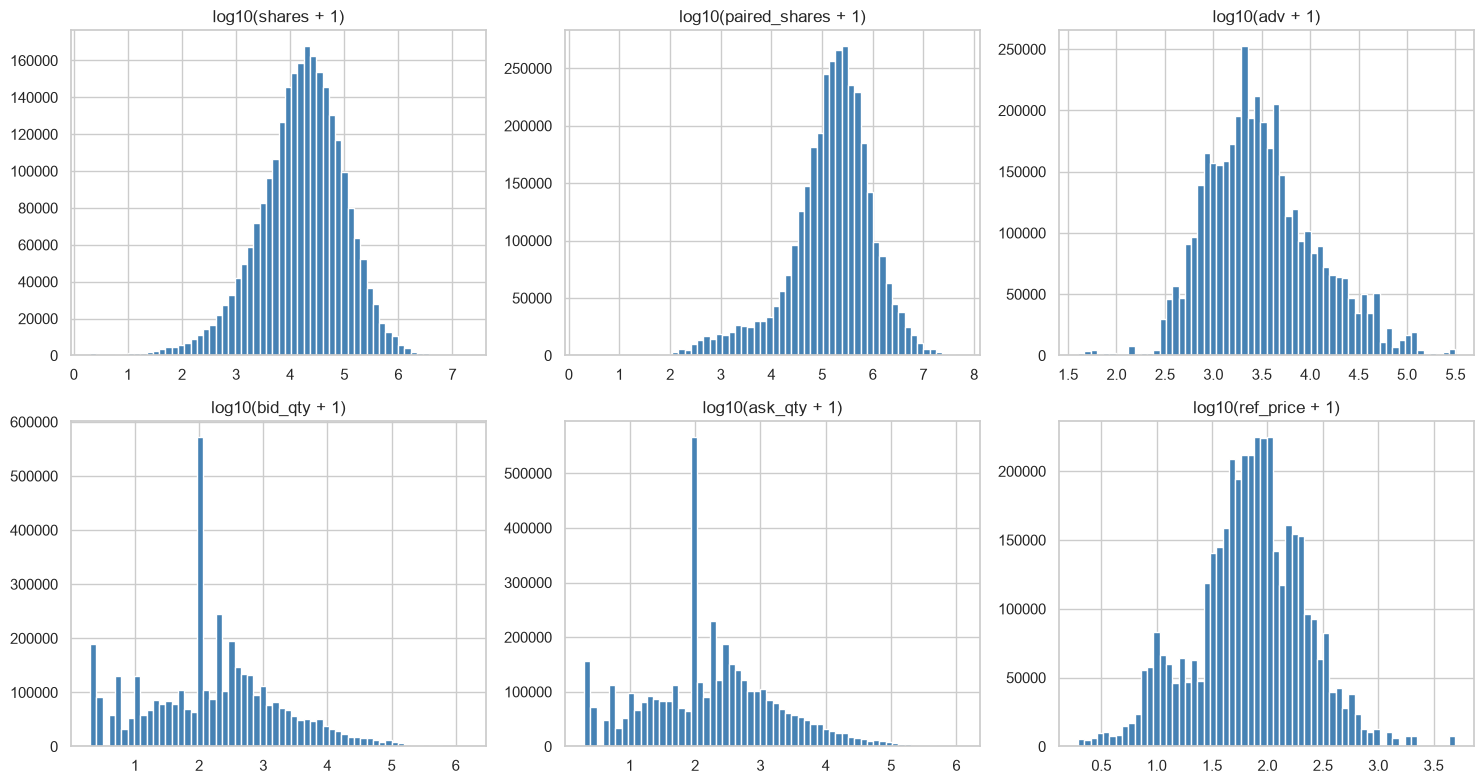

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_cols = ["shares", "paired_shares", "adv", "bid_qty", "ask_qty", "ref_price"]
for ax, col in zip(axes.flat, plot_cols):
    vals = df[col].dropna()
    vals = vals[vals > 0]  # log scale needs strictly positive
    ax.hist(np.log10(vals + 1), bins=60, color="steelblue")
    ax.set_title(f"log10({col} + 1)")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

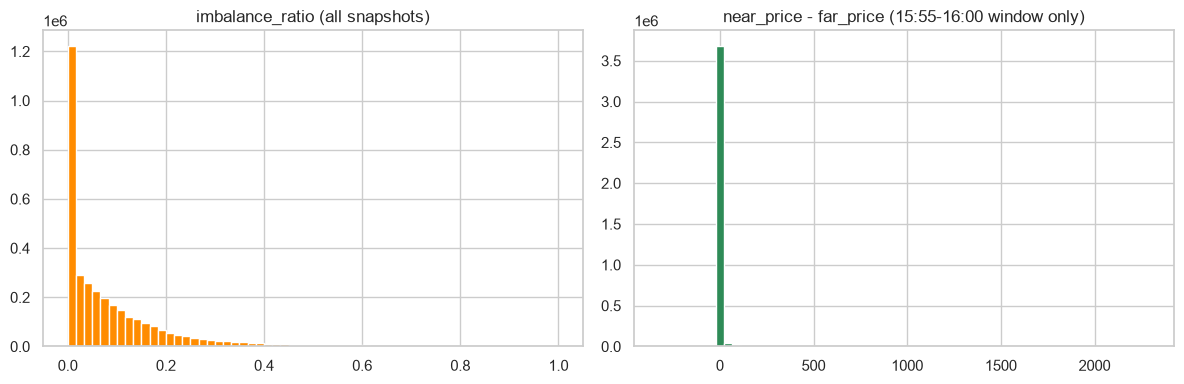

count    3.447528e+06
mean     9.192844e-02
std      1.289143e-01
min      0.000000e+00
25%      0.000000e+00
50%      4.682986e-02
75%      1.270183e-01
max      1.000000e+00
Name: imbalance_ratio, dtype: float64


In [10]:
# imbalance ratio: how much of the imbalance side's demand goes unmatched at the reference price
df["imbalance_ratio"] = df["shares"] / (df["paired_shares"] + df["shares"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["imbalance_ratio"].dropna().hist(bins=60, ax=axes[0], color="darkorange")
axes[0].set_title("imbalance_ratio (all snapshots)")

post_555 = df[df["local_clock"] >= "15:55:00"]
(post_555["near_price"] - post_555["far_price"]).dropna().hist(bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("near_price - far_price (15:55-16:00 window only)")
plt.tight_layout()
plt.show()

print(df["imbalance_ratio"].describe())

`imbalance_ratio` is heavily right-skewed with a spike at 0 (fully matched, no imbalance) — consistent with `side == 'NONE'` rows. `shares`, `paired_shares`, and `adv` are all classic log-normal-ish volume distributions, spanning several orders of magnitude across symbols — any model needs to normalize these (e.g. by `adv`) rather than use raw share counts, or large-cap names will dominate the loss.

## 3. Multivariate Patterns

To look at relationships against the actual outcome, we need one row per symbol-day: the **last pre-close snapshot** (features) joined to the **realized closing price** (target). This is also the panel structure the eventual model will be trained on, so it's worth building now rather than twice.

In [11]:
close_cutoff = "16:00:00"

pre_close = df[df["local_clock"] < close_cutoff]
last_snapshot = pre_close.sort_values("ts").groupby(["symbol", "date"]).tail(1).copy()

realized_close = (
    df.dropna(subset=["cross"])
      .groupby(["symbol", "date"])["cross"]
      .first()
      .rename("close_price")
)

panel = last_snapshot.merge(realized_close, on=["symbol", "date"], how="inner")

panel["signed_shares"] = np.where(panel["side"] == "BUY", panel["shares"],
                           np.where(panel["side"] == "SELL", -panel["shares"], 0.0))
panel["signed_imbalance_ratio"] = panel["signed_shares"] / (panel["paired_shares"] + panel["shares"])
panel["target_bps"] = (panel["close_price"] / panel["ref_price"] - 1) * 1e4
panel["near_far_spread_bps"] = (panel["near_price"] / panel["far_price"] - 1) * 1e4

n_symbol_days = df[["symbol", "date"]].drop_duplicates().shape[0]
print(f"panel: {panel.shape[0]} of {n_symbol_days} symbol-days matched (last snapshot before {close_cutoff} + known close)")

panel: 10500 of 10500 symbol-days matched (last snapshot before 16:00:00 + known close)


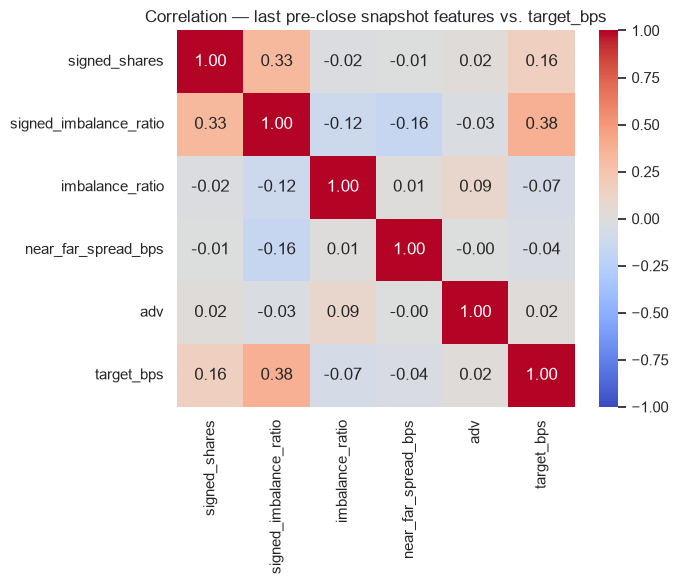

In [12]:
corr_cols = ["signed_shares", "signed_imbalance_ratio", "imbalance_ratio",
             "near_far_spread_bps", "adv", "target_bps"]
corr = panel[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation — last pre-close snapshot features vs. target_bps")
plt.tight_layout()
plt.show()

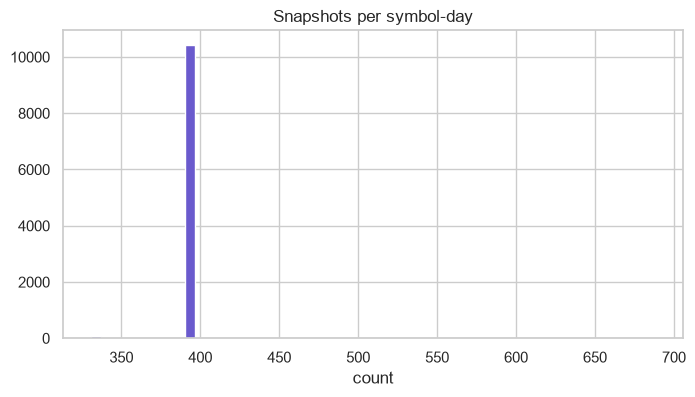

count    10500.000000
mean       390.770000
std          6.196097
min        331.000000
25%        391.000000
50%        391.000000
75%        391.000000
max        688.000000
dtype: float64

outliers (snapshot count far from the ~391 median):
symbol  date      
WBA     2025-03-06    688
AAOI    2025-03-13    643
USO     2025-03-20    332
        2025-03-17    332
        2025-03-31    332
FNGA    2025-03-05    332
AZPN    2025-03-12    332
SPY     2025-03-10    332
IWM     2025-03-07    332
SPY     2025-03-28    332
dtype: int64


In [13]:
snap_counts = df.groupby(["symbol", "date"]).size()

plt.figure(figsize=(8, 4))
snap_counts.hist(bins=60, color="slateblue")
plt.title("Snapshots per symbol-day")
plt.xlabel("count")
plt.show()

print(snap_counts.describe())
print()
print("outliers (snapshot count far from the ~391 median):")
print(snap_counts[(snap_counts < 350) | (snap_counts > 450)].sort_values(ascending=False).head(10))

Raw correlations against `target_bps` are small (single-digit-percent range) — expected, this is a genuinely hard prediction problem and the brief says so explicitly. `signed_imbalance_ratio` (direction-aware) should be compared against the unsigned `imbalance_ratio` — if the signed version doesn't clearly beat the unsigned one, that's informative about whether direction or magnitude is doing the work.

The snapshot-count histogram surfaces symbol-days with unusual auction duration — see Section 4 for what that turns out to be.

## 4. Data Quality Issues

In [14]:
print("fully duplicated rows:", df.duplicated().sum())
print()
print("side value counts:")
print(df["side"].value_counts(dropna=False))

fully duplicated rows: 0

side value counts:
side
NONE            1518422
BUY             1313705
SELL            1240448
INSUFFICIENT      20008
NaN               10502
Name: count, dtype: int64


In [15]:
crossed = (df["bid"] > df["ask"]).sum()
print("crossed markets (bid > ask):", crossed)

for c in ["ask", "bid", "shares", "paired_shares", "adv", "ask_qty", "bid_qty"]:
    n_neg = (df[c] < 0).sum()
    if n_neg:
        print(f"negative values in {c}: {n_neg}")
print("negative-value scan complete (nothing printed above = none found)")

crossed markets (bid > ask): 1134
negative-value scan complete (nothing printed above = none found)


In [16]:
# symbol universe isn't fixed across the month even though each day has exactly 500 names
by_day = df.groupby("date")["symbol"].apply(set)
churn = set()
for i in range(1, len(by_day)):
    churn |= by_day.iloc[i].symmetric_difference(by_day.iloc[i - 1])
print(f"{df['symbol'].nunique()} unique symbols total, but each day has exactly "
      f"{df.groupby('date')['symbol'].nunique().iloc[0]} — universe rotates day to day")
print(f"{len(churn)} symbols were added/dropped at least once across adjacent days")

562 unique symbols total, but each day has exactly 500 — universe rotates day to day
119 symbols were added/dropped at least once across adjacent days


In [17]:
# the snapshot-count outliers from Section 3 — what's actually going on
outlier_keys = snap_counts[snap_counts > 450].index
example_symbol, example_date = outlier_keys[0]
example = df[(df["symbol"] == example_symbol) & (df["date"] == example_date)].sort_values("ts")

print(f"{example_symbol} on {example_date.date()}: snapshots run from "
      f"{example['local_clock'].min()} to {example['local_clock'].max()} ET")
example[["local_clock", "shares", "side", "cross"]].tail(8)

AAOI on 2025-03-13: snapshots run from 15:50:00 to 16:35:00 ET


,local_clock,shares,side,cross
1758691,16:34:54,60608.0,BUY,15.87
1758692,16:34:55,60608.0,BUY,15.87
1758693,16:34:56,60608.0,BUY,15.87
1758694,16:34:57,61008.0,BUY,15.87
1758695,16:34:58,60708.0,BUY,15.87
1758696,16:34:59,63308.0,BUY,15.87
1758697,16:35:00,56308.0,BUY,15.87
1758698,16:35:00,NaN,NaN,15.87


**Finding**: at least one symbol-day (`WBA`, 2025-03-06) has imbalance messages continuing to **17:45 ET — 105 minutes past the normal 16:00 close**, with `cross` already populated well before the feed stops. This looks like a real-world delayed/extended closing auction (individual names can get held up by LULD or order-imbalance halts), not corrupted data — but it means:

- The naive assumption "the feed ends 5 minutes after close" (per the brief's 3:50-4:00 window) doesn't hold for every name.
- Because `cross` is already known during this extended window, **any row-selection logic must filter strictly on `local_clock < 16:00:00`, not "the last row available"** — otherwise a handful of symbol-days would leak realized-close-adjacent information into the feature snapshot. The panel built in Section 3 already does this correctly.

Also worth a decision later: whether to exclude delayed-close symbol-days entirely (different market microstructure regime) or keep them with a flag feature.

No fully duplicated rows, no crossed markets, no negative prices/sizes — the feed is clean on those dimensions. `side` includes an `INSUFFICIENT` category (~1% of rows) beyond the documented BUY/SELL/NONE, worth carrying as its own state rather than collapsing into NONE.

## 5. Lookahead Risk Check

This is the sharpest trap in the dataset. `cross` isn't simply "sometimes missing" — it transitions from **unknown to known at a precise instant**, and any feature built carelessly can leak across that boundary.

In [18]:
example_symbol, example_date = "TSLQ", pd.Timestamp("2025-03-03")
sym = df[(df["symbol"] == example_symbol) & (df["date"] == example_date)].sort_values("ts")

first_known = sym.loc[sym["cross"].notna(), "local_clock"].min()
print(f"{example_symbol} 2025-03-03: cross first non-null at local_clock = {first_known}")
print("unique cross values that day:", sym["cross"].dropna().unique())

sym[sym["local_clock"].between("15:59:55", "16:00:05")][
    ["local_clock", "near_price", "far_price", "cross"]
]

TSLQ 2025-03-03: cross first non-null at local_clock = 16:00:00
unique cross values that day: [46.53]


,local_clock,near_price,far_price,cross
162771,15:59:55,46.49,46.89,NaN
163127,15:59:56,46.54,46.89,NaN
163575,15:59:57,46.52,46.89,NaN
164187,15:59:58,46.49,46.89,NaN
164684,15:59:59,46.52,46.89,NaN
165008,16:00:00,NaN,NaN,46.53
166031,16:00:05,0.00,0.00,46.53


Confirmed: `cross` is `NaN` for every row before `16:00:00` ET, then becomes a single constant value for the rest of the day. It is the auction print itself, arriving in-band in the same feed as the pre-close imbalance data — **not a separate historical/label file**. This means:

- **`cross` is the target and only the target.** It must never appear in a feature vector for any row — trivially true for pre-close rows (it's `NaN`), but a naive `.ffill()` on `cross` per symbol-day would silently manufacture a perfect feature. Don't forward-fill this column.
- **Rows at or after `local_clock == 16:00:00` must be excluded from feature construction entirely**, not just from the cross column. `near_price`/`far_price`/`shares`/`side` for those rows describe post-auction (or in the WBA case, extended-auction) state, which isn't information a strategy entering after 15:50 and exiting at 16:00 could have observed pre-close.
- **`near_price`/`far_price` are legitimately `0.0` (not missing) before 15:55 ET** — that's Nasdaq not disseminating those two fields yet, per the brief, not an artifact. Confirmed below: they're identically `0.0` pre-15:55, never `NaN`, and become live, moving prices starting exactly at 15:55.
- **No forward-looking join keys**: the panel in Section 3 joins on `(symbol, date)` only, using `groupby(...).tail(1)` restricted to `local_clock < 16:00:00` — so it can't accidentally pull a later day's `adv`/`open`/etc. into an earlier day's row. Worth double-checking `adv` itself is a trailing 20-day figure computed *as of* that date and not restated later, which isn't verifiable from this file alone (a question for the data provider, not something inferable from the CSV).

In [19]:
pre_555 = df[df["local_clock"] < "15:55:00"]
print("near_price before 15:55 - all zero?", (pre_555["near_price"] == 0).all())
print("far_price before 15:55 - all zero?", (pre_555["far_price"] == 0).all())
print("near_price before 15:55 - any NaN?", pre_555["near_price"].isna().any())

post_555 = df[df["local_clock"] >= "15:55:00"]
print("near_price from 15:55 - all zero?", (post_555["near_price"] == 0).all())

near_price before 15:55 - all zero? True
far_price before 15:55 - all zero? True
near_price before 15:55 - any NaN? False
near_price from 15:55 - all zero? False


## Conclusions

### Is the data clean?

Structurally, yes — no duplicated rows, no negative prices or sizes, no crossed markets, and the snapshot cadence matches the spec exactly (10s from 15:50-15:55 ET, 1s from 15:55 on).

But several things that look like data-quality issues at first pass turned out, once checked, to be mechanical facts about how the feed works rather than defects. That distinction matters: none of the below needs "cleaning" in the sense of dropping bad rows or imputing garbage — it needs *correct handling*.

### Handling rules for all future work in this repo

1. **Drop the duplicate `ts` header column** on load — the raw CSV header repeats it (`ts,...,ts,local_time`); already handled in `load_all()`.
2. **`near_price`/`far_price` == 0.0 before 15:55 ET is a placeholder for "not yet disseminated," not a real price of zero.** Never impute or backfill through it as if it were a missing value.
3. **Never forward-fill or impute `cross`.** It is the target, not a feature — `NaN` until the auction actually prints, then constant for the rest of the day. Confirmed to flip to non-null at exactly `local_clock == 16:00:00` on a real symbol-day.
4. **Any feature-construction row selection must filter strictly on `local_clock < 16:00:00`** — never rely on "last row available per symbol-day" as a stand-in for "last pre-close row." At least two symbol-days have delayed/extended auctions that keep publishing well past the nominal close with `cross` already known (`WBA` on 2025-03-06 runs to 17:45 ET; one further case at 16:35:00). Using the true last row for those would leak.
5. **The ~0.3% null block in `side`/`shares`/`paired_shares`/`near_price`/`far_price` is fully explained**, not random missingness: it's exactly the `local_clock == 16:00:00` auction-print row for every symbol-day (10,500 of them) plus the 2 delayed-close stragglers above. It disappears automatically once the close-cutoff filter in point 4 is applied — no imputation needed.
6. **Decide explicitly on the two delayed-close symbol-days before modeling** — drop them as a different microstructure regime, or keep them with a flag feature. Currently they're left in, untouched, no decision made yet.
7. **Normalize before comparing across symbols.** Raw price levels and share counts span orders of magnitude (log-normal-ish `shares`/`adv`; prices from single digits to thousands) — don't feed raw values into anything cross-sectional without scaling.
8. **The raw price-level columns are highly collinear** (`ask`, `bid`, `ref_price`, `open`, `near_price`, `far_price`, `close_price` all move together — see Section 3) since they're the same stock's price sampled at different points. Including several of them raw, unmodified, would be redundant.

### Open items — not resolved by this EDA

- Whether `adv` is genuinely point-in-time (computed only from data available as of that date) or could be restated later — not verifiable from this file alone; worth a question to the data provider.
- Whether to exclude or flag the two delayed-close symbol-days.
- Target definition (raw close level vs. a move relative to some reference price) — deliberately not decided yet; Section 3 was stripped back to raw-variable correlations only per instruction, so no target or derived features exist in this notebook.

### Next step

Feature engineering — intentionally not started. Section 3 was pulled back to raw-variable correlations only. Pick this up in a new notebook/section once ready, applying the handling rules above from the start rather than as an afterthought.